##**Step1:** Uploading the file

In [1]:
from google.colab import files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red (1).csv


##**Step 2:** Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import SGDClassifier

# Purpose: RandomForestClassifier, SGDClassifier, and SVC are the three required classifiers. StandardScaler is needed because SVC and SGD are distance/gradient-based and sensitive to feature scale, unlike Random Forest. The metrics imports let us evaluate each model properly.

##**Step 3:** Loading the Dataset

In [3]:
df = pd.read_csv('/content/winequality-red.csv', sep=';')
df.head()

# Purpose: This file uses semicolons, not commas. Without sep=';', all 12 columns collapse into one

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**Initial Load:**
Loaded the Red Wine Quality dataset — 1,599 samples with 11 physicochemical features and a quality score (target variable) ranging from 3 to 8.

##**Step 4:** Inspect Structure & Class Distribution

In [4]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nQuality score distribution:\n", df['quality'].value_counts().sort_index())

# Purpose: Confirms no missing values, and shows exactly how many wines fall into each quality score; critical before modeling since this reveals class imbalance.

Shape: (1599, 12)

Missing values:
 0

Quality score distribution:
 quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


**Data Quality Report:**
No missing values. Quality scores range from 3 to 8, but the distribution is highly uneven: scores 5 and 6 dominate (681 and 638 samples respectively), while extreme scores like 3 (10 samples) and 8 (18 samples) are very rare.



##**Step 5:** EDA: Distribution Plots for All Features

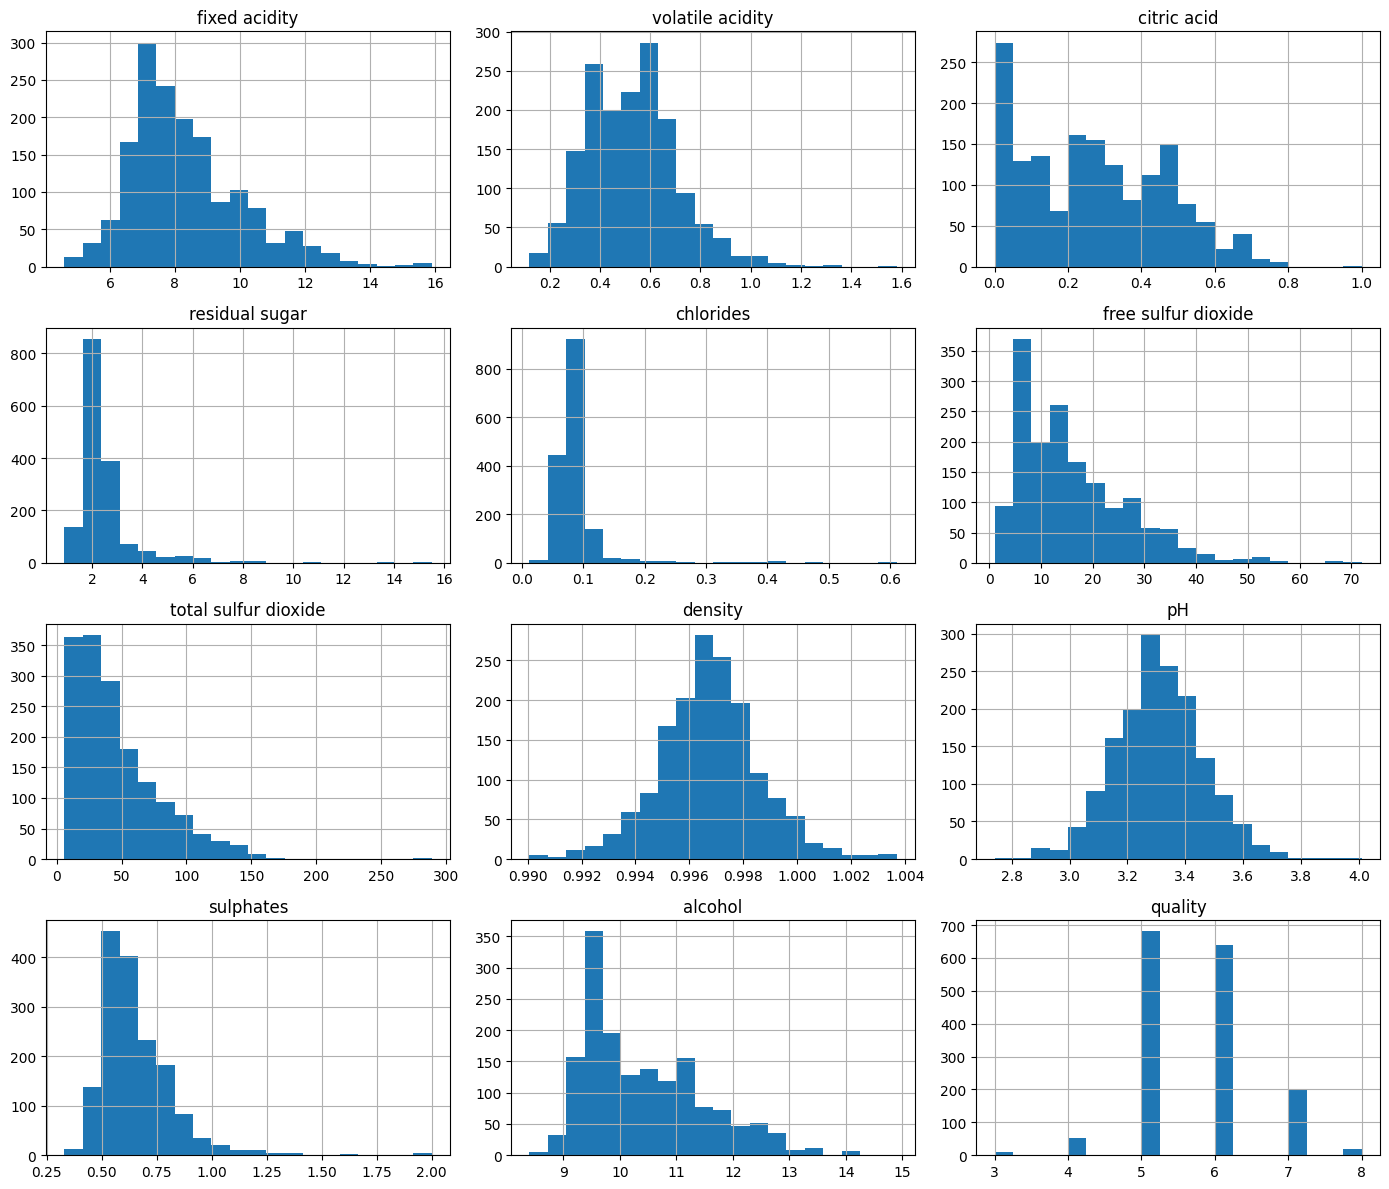

In [5]:
df.hist(figsize=(14,12), bins=20)
plt.tight_layout()
plt.show()

# Purpose: .hist() on the whole dataframe plots a histogram for every numeric column at once — a fast way to see the shape (skew, spread, outliers) of all 11 chemical features together.

**Observation:**
Most features show a roughly normal or right-skewed distribution. Quality itself is concentrated around 5–6, confirming the imbalance seen in the value counts above.

##**Step 6:** Correlation Heatmap

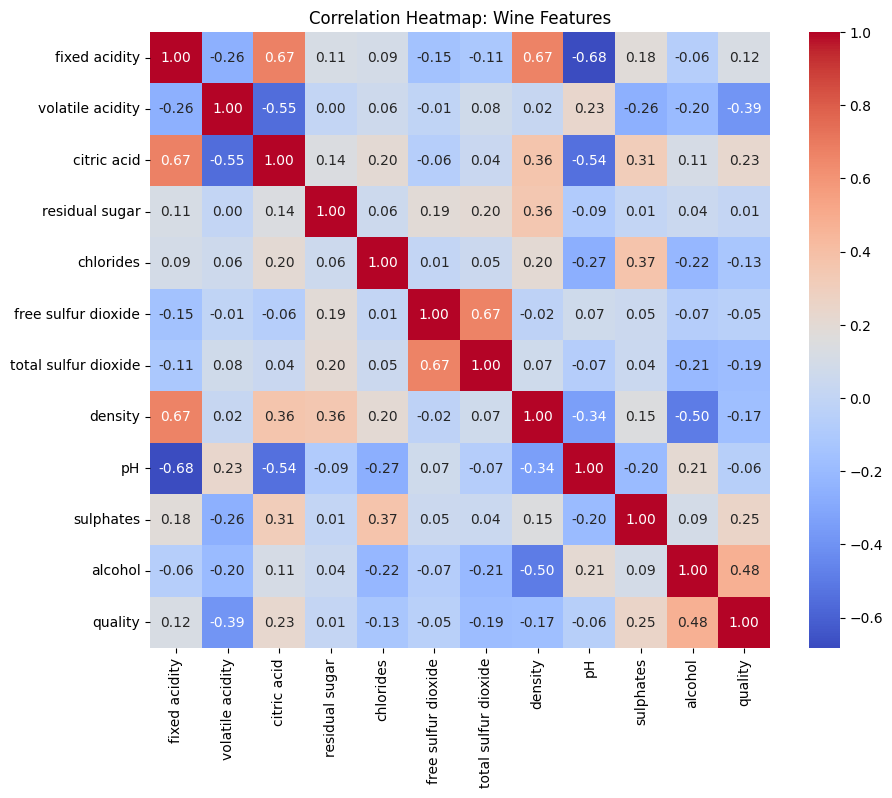

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Wine Features')
plt.show()

# Purpose: Shows how each chemical feature relates to quality and to each other, helps identify which features are likely to matter most for prediction.

**Observation:**
Alcohol has the strongest positive correlation with quality (0.48), followed by sulphates (0.25) and citric acid (0.23). Volatile acidity has the strongest negative correlation (-0.39) — higher volatile acidity tends to mean lower quality wine. This aligns with wine chemistry: volatile acidity relates to spoilage/vinegar taste.

##**Step 7:** Discussing Class Imbalance

### **Class Imbalance Discussion**
The quality scores are heavily imbalanced, scores 5 and 6 make up about 82% of all samples (1,319 out of 1,599), while scores 3, 4, and 8 combined make up only about 5%. If we train a classifier directly on all 6 classes, it will struggle to learn the rare classes (3, 4, 8) since it barely sees examples of them, and accuracy alone would be misleading, a model could get high accuracy just by always predicting 5 or 6.

##**Step 8:** Feature Engineering: Bin Quality into 3 Classes

In [7]:
def quality_to_label(q):
    if q <= 4:
        return 'low'
    elif q <= 6:
        return 'medium'
    else:
        return 'high'

df['quality_label'] = df['quality'].apply(quality_to_label)
print(df['quality_label'].value_counts())

# Purpose: Rather than predicting 6 rare fine-grained scores, we group them into 3 broader classes (low/medium/high). This is a standard, defensible approach for this dataset; it reduces the imbalance problem while still being a meaningful business question ("is this wine low, medium, or high quality?").

quality_label
medium    1319
high       217
low         63
Name: count, dtype: int64


**Decision: Binning Justification**
Quality scores were grouped into 3 classes: low (3-4), medium (5-6), high (7-8), rather than kept as 6 separate classes. This reduces the severity of class imbalance and produces a more practically useful classification (a wine buyer cares whether a wine is "good," not the exact numeric score), while still preserving meaningful distinctions.

##**Step 9:** Prepare Features and Target

In [8]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Purpose: X contains only the 11 chemical features (dropping both quality columns since those are what we're predicting). Scaling is essential here since SVC and SGD are sensitive to feature magnitude differences (e.g., total sulfur dioxide is in the hundreds, while density is close to 1).

##**Step 10:** Train/Test Split with Stratification

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

# Purpose: stratify=y ensures the train and test sets preserve the same proportion of low/medium/high wines as the full dataset without this, a random split could accidentally leave very few "low" or "high" examples in the test set, making evaluation unreliable.

Train class distribution:
 quality_label
medium    1055
high       174
low         50
Name: count, dtype: int64

Test class distribution:
 quality_label
medium    264
high       43
low        13
Name: count, dtype: int64


##**Step 11:** Train All 3 Classifiers

In [10]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# SGD Classifier
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train, y_train)
sgd_pred = sgd.predict(X_test)

# SVC
svc = SVC(random_state=42)
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)

# Purpose: Trains all three required models on the same scaled, stratified training data so their results are directly comparable.

##**Step 12:** Evaluate Each Model

In [11]:
for name, pred in [('Random Forest', rf_pred), ('SGD', sgd_pred), ('SVC', svc_pred)]:
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred, zero_division=0))
    print()

# Purpose: Loops through all three models' predictions, printing accuracy plus the full classification report (precision, recall, F1-score per class).

--- Random Forest ---
Accuracy: 0.86875
              precision    recall  f1-score   support

        high       0.72      0.53      0.61        43
         low       0.00      0.00      0.00        13
      medium       0.89      0.97      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.50      0.51       320
weighted avg       0.83      0.87      0.84       320


--- SGD ---
Accuracy: 0.828125
              precision    recall  f1-score   support

        high       0.55      0.14      0.22        43
         low       0.00      0.00      0.00        13
      medium       0.84      0.98      0.90       264

    accuracy                           0.83       320
   macro avg       0.46      0.37      0.38       320
weighted avg       0.76      0.83      0.78       320


--- SVC ---
Accuracy: 0.84375
              precision    recall  f1-score   support

        high       0.64      0.33      0.43        43
         low       0.00   

**Observation:**
Random Forest achieved the highest accuracy at 86.9%, followed by SVC (84.4%) and SGD (82.8%). However, accuracy alone hides an important problem: **all three models completely failed to correctly identify any "low" quality wines** (0.00 precision, recall, and F1-score for that class across every model). This happened because the training set only contained 50 "low" examples compared to 1,055 "medium" examples — the models essentially never learned to recognize this rare class and default to predicting "medium" instead. The "medium" class, unsurprisingly, had the strongest performance across all models (F1-scores of 0.90–0.92), since it dominates the dataset.

##**Step 13:** Confusion Matrices

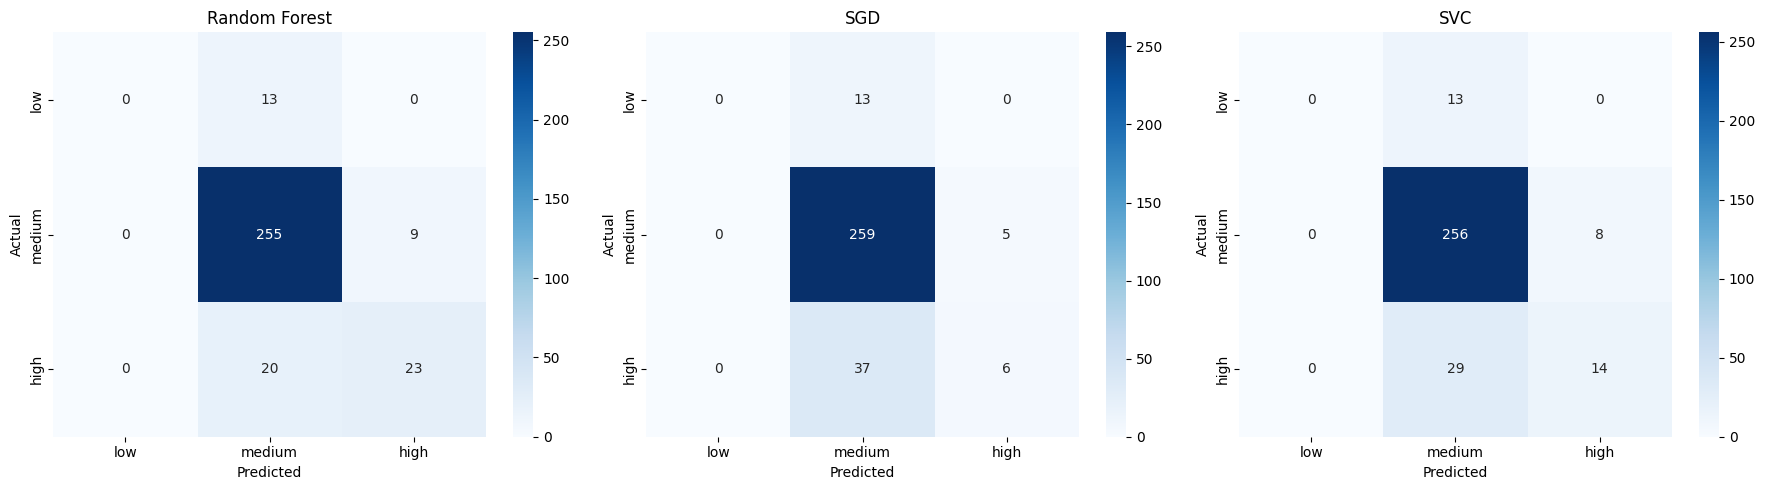

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (name, pred) in zip(axes, [('Random Forest', rf_pred), ('SGD', sgd_pred), ('SVC', svc_pred)]):
    cm = confusion_matrix(y_test, pred, labels=['low','medium','high'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['low','medium','high'], yticklabels=['low','medium','high'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Purpose: Shows exactly where each model gets confused e.g., predicting "medium" when the true label was "low." This is more informative than accuracy alone, especially with imbalanced classes.

##**Step 14:** Feature Importance (Random Forest)

/tmp/ipykernel_4247/3821032409.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


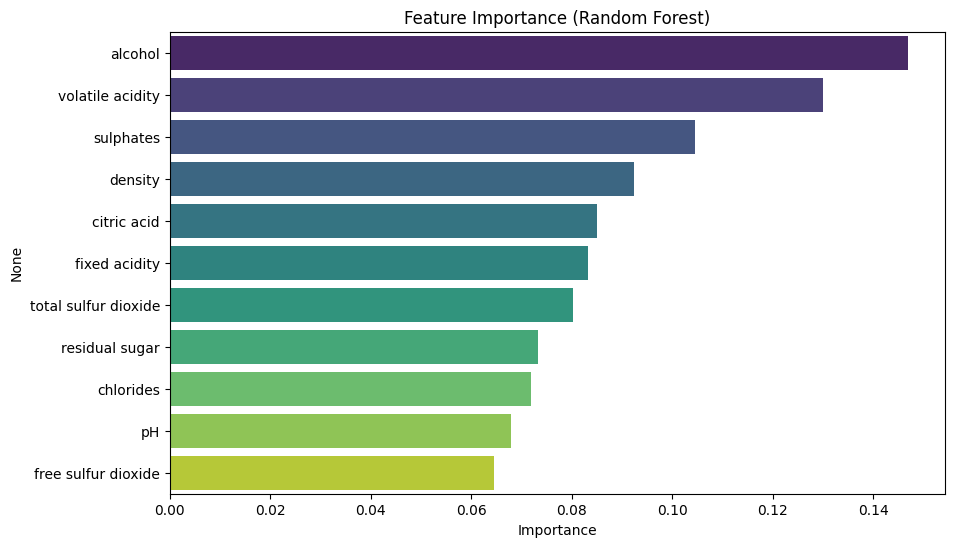

In [13]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

# Purpose: Random Forest can directly report which features it relied on most for its decisions, this only applies to Random Forest (not SVC or SGD).

**Observation:**
**Alcohol** (0.147) and **volatile acidity** (0.130) emerged as the two most important predictors, followed by sulphates (0.104). This matches the earlier correlation heatmap findings almost exactly — alcohol had the strongest positive correlation with quality, and volatile acidity had the strongest negative correlation. This consistency between two different analytical methods (correlation and feature importance) adds confidence that these are genuinely the features driving wine quality, not statistical noise.

##**Step 15:** Comparison Table

In [14]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD', 'SVC'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, sgd_pred), accuracy_score(y_test, svc_pred)]
})
comparison.sort_values('Accuracy', ascending=False)


,Model,Accuracy
0,Random Forest,0.868750
2,SVC,0.843750
1,SGD,0.828125


##**Step 16:** Conclusion

## **Conclusion**
Random Forest performed best overall with 86.9% accuracy, likely because it handles non-linear relationships between chemical features well and is naturally more robust to class imbalance than SGD's linear decision boundaries or SVC's margin-based approach, its ensemble structure means it isn't as easily dominated by the majority class.

For deployment, Random Forest is recommended, given its higher accuracy and its ability to provide interpretable feature importance scores, which is valuable for a business trying to understand *why* a wine is rated a certain way, not just what the rating is.

However, a critical limitation across all three models is that **none of them could correctly identify any "low quality" wines** in the test set precision, recall, and F1-score were all 0.00 for this class, entirely because the training data contained only 50 "low" examples versus 1,055 "medium" examples. This means the current models are only reliable for distinguishing "medium" from "high" quality wines, and would need either more "low" quality training samples or a class-imbalance technique (such as SMOTE oversampling or class weighting) before being trusted to catch genuinely poor-quality wine in a real deployment.